# Modelo LTV LM

### Analisis de Cohorte

Cargando datos para análisis de cohortes...
Identificando primera compra de cada cliente...
Calculando cohortes mensuales...
Creando matriz de cohortes...
Calculando tasas de retención...
Analizando tasas de recompra...
Generando visualizaciones...


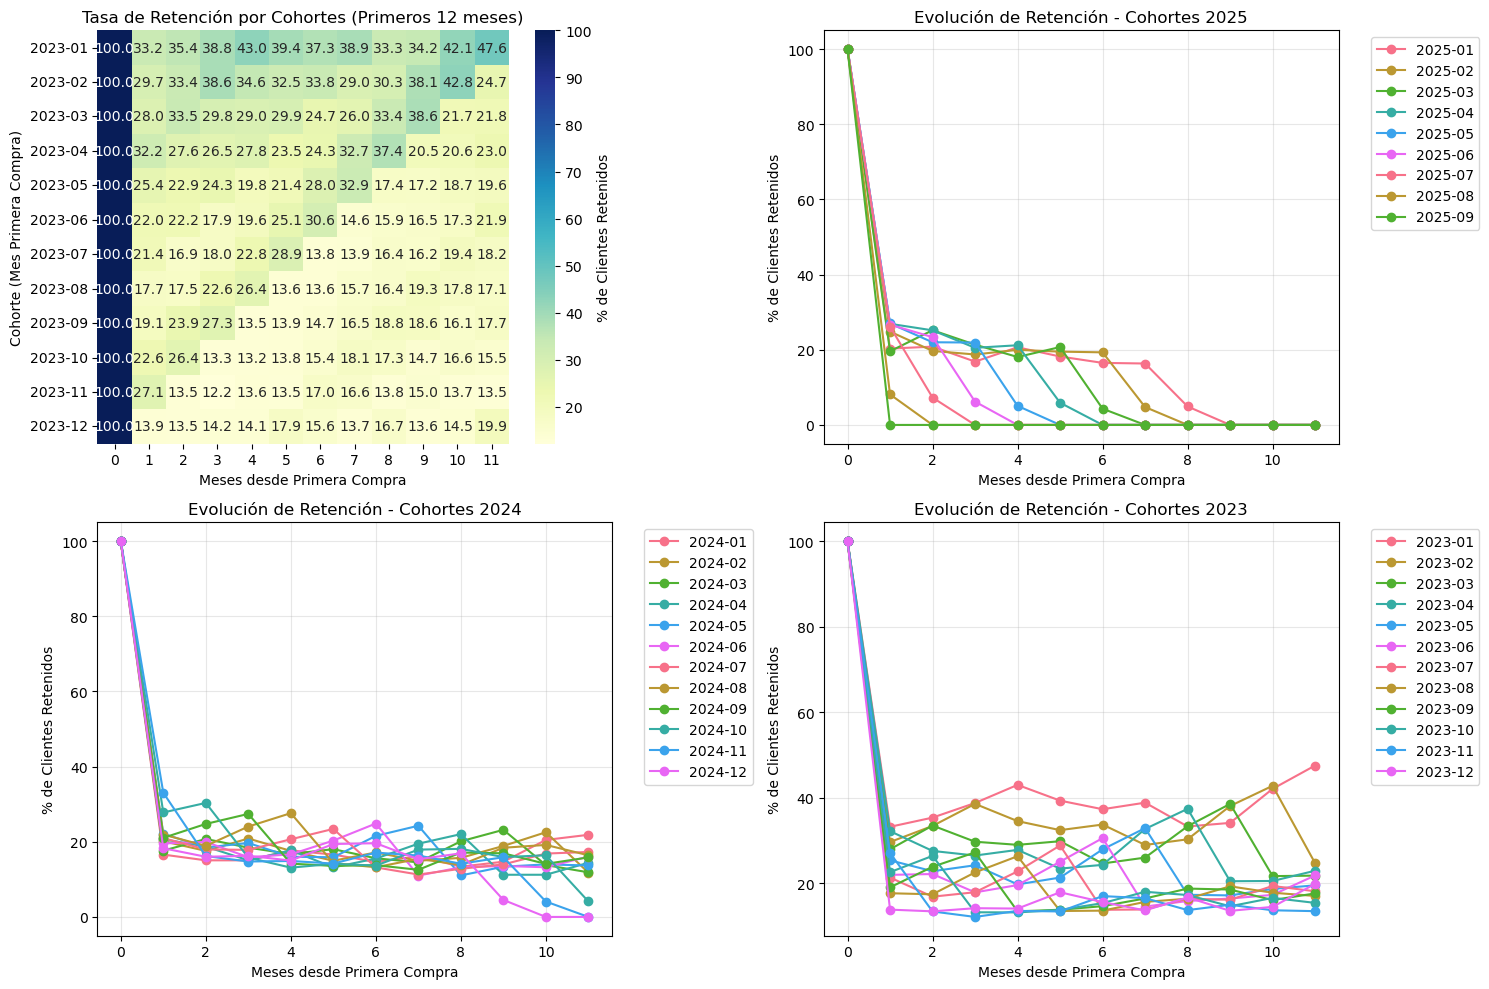

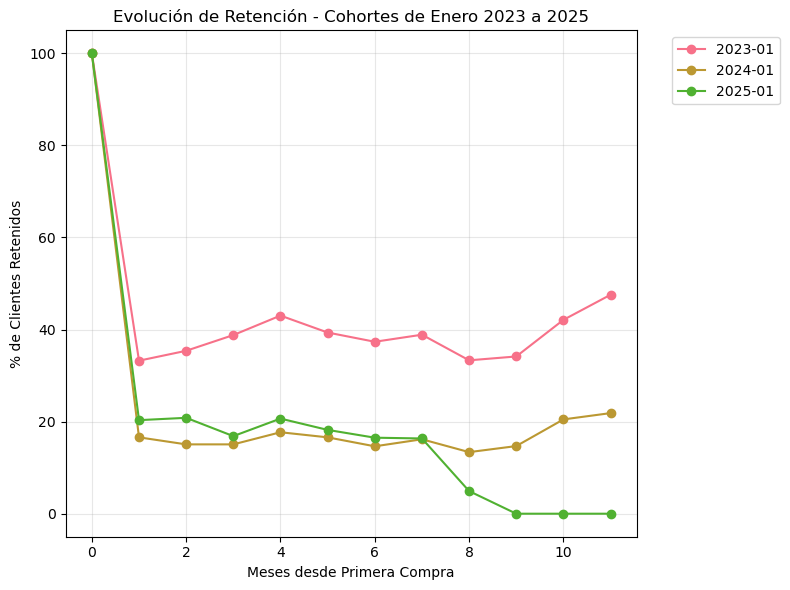


ANÁLISIS DE COHORTES - ESTADÍSTICAS PRINCIPALES

1. TASA DE RETENCIÓN PROMEDIO:
   - A 3 meses: 18.5%
   - A 6 meses: 15.4%
   - A 12 meses: 12.9%

2. TASA DE RECOMPRA PROMEDIO:
   - Mes 1: 97.0%
   - Mes 3: 90.9%
   - Mes 6: 81.8%

3. COHORTES CON MEJOR DESEMPEÑO:
   - Mejor retención a 3 meses: 2023-01
   - Mejor retención a 6 meses: 2023-01

4. TENDENCIA TEMPORAL:
   - Cambio en retención a 3 meses: -38.8%

5. ESTADÍSTICAS DE CLIENTES:
   - Total de clientes únicos: 141,889
   - Total de cohortes analizadas: 33
   - Tamaño promedio de cohorte: 4300 clientes
   - Cohorte más grande: 24,338.0 clientes (2023-01)
   - Cohorte más pequeña: 288.0 clientes (2025-09)


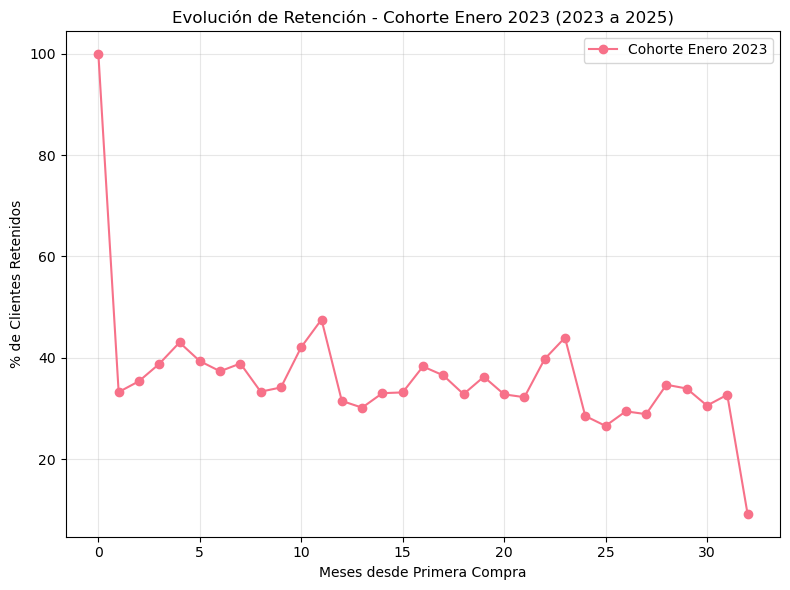

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")

# Cargar datos
print("Cargando datos para análisis de cohortes...")
df = pd.read_csv(r'.\Dataframes LM\Historico-CompraLM.csv', encoding='latin-1', low_memory=False)

# Preprocesamiento básico de fechas
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
df = df.dropna(subset=['Fecha', 'CUENTA'])

# Ordenar por fecha
df = df.sort_values(['CUENTA', 'Fecha'])

# 1. IDENTIFICAR PRIMERA COMPRA DE CADA CLIENTE
print("Identificando primera compra de cada cliente...")
primera_compra = df.groupby('CUENTA')['Fecha'].min().reset_index()
primera_compra.rename(columns={'Fecha': 'Primera_Compra'}, inplace=True)

# Unir con datos originales
df_cohort = df.merge(primera_compra, on='CUENTA')

# 2. CALCULAR COHORTES POR MES DE PRIMERA COMPRA
print("Calculando cohortes mensuales...")
df_cohort['Cohort_Mes'] = df_cohort['Primera_Compra'].dt.to_period('M')
df_cohort['Mes_Compra'] = df_cohort['Fecha'].dt.to_period('M')

# 3. CALCULAR NÚMERO DE MESES DESDE PRIMERA COMPRA
df_cohort['Meses_Desde_Primera'] = (
    (df_cohort['Mes_Compra'].dt.year - df_cohort['Cohort_Mes'].dt.year) * 12 +
    (df_cohort['Mes_Compra'].dt.month - df_cohort['Cohort_Mes'].dt.month)
)

# 4. MATRIZ DE COHORTES - CLIENTES ACTIVOS POR MES
print("Creando matriz de cohortes...")
cohort_data = df_cohort.groupby(['Cohort_Mes', 'Meses_Desde_Primera'])['CUENTA'].nunique().reset_index()
cohort_pivot = cohort_data.pivot_table(index='Cohort_Mes', 
                                      columns='Meses_Desde_Primera', 
                                      values='CUENTA', 
                                      fill_value=0)

# 5. CALCULAR TASA DE RETENCIÓN
print("Calculando tasas de retención...")
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100

# 6. ANÁLISIS DE RECOMPRA
print("Analizando tasas de recompra...")
# Identificar si un cliente recompró en cada mes
recompra_data = df_cohort.groupby(['CUENTA', 'Mes_Compra']).size().reset_index()
recompra_data['Recompro'] = 1

# Calcular tasa de recompra por cohorte
recompra_cohort = df_cohort.merge(recompra_data, on=['CUENTA', 'Mes_Compra'], how='left')
recompra_cohort['Recompro'] = recompra_cohort['Recompro'].fillna(0)

tasa_recompra = recompra_cohort.groupby(['Cohort_Mes', 'Meses_Desde_Primera'])['Recompro'].mean().reset_index()
tasa_recompra_pivot = tasa_recompra.pivot_table(index='Cohort_Mes', 
                                               columns='Meses_Desde_Primera', 
                                               values='Recompro', 
                                               fill_value=0) * 100

# 7. VISUALIZACIONES
print("Generando visualizaciones...")

# Heatmap de Retención
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.heatmap(retention_matrix.iloc[:12, :12], 
            annot=True, fmt='.1f', cmap='YlGnBu', 
            cbar_kws={'label': '% de Clientes Retenidos'})
plt.title('Tasa de Retención por Cohortes (Primeros 12 meses)')
plt.ylabel('Cohorte (Mes Primera Compra)')
plt.xlabel('Meses desde Primera Compra')
 
# Evolución de la Retención
plt.subplot(2, 2, 2)
cohortes_2025 = retention_matrix[retention_matrix.index.astype(str).str.startswith("2025-")]
for cohorte in cohortes_2025.index:
    plt.plot(cohortes_2025.columns[:12], 
             cohortes_2025.loc[cohorte].values[:12], 
             marker='o', label=str(cohorte))
plt.title('Evolución de Retención - Cohortes 2025')
plt.xlabel('Meses desde Primera Compra')
plt.ylabel('% de Clientes Retenidos')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Evolución de la Retención - Cohortes de 2024
plt.subplot(2, 2, 3)  # <- nueva posición en la cuadrícula de 2x2
cohortes_2024 = retention_matrix[retention_matrix.index.astype(str).str.startswith("2024")]
for cohorte in cohortes_2024.index:
    plt.plot(cohortes_2024.columns[:12], 
             cohortes_2024.loc[cohorte].values[:12], 
             marker='o', label=str(cohorte))
plt.title('Evolución de Retención - Cohortes 2024')
plt.xlabel('Meses desde Primera Compra')
plt.ylabel('% de Clientes Retenidos')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Evolución de la Retención - Cohortes de 2023 (desde enero)
plt.subplot(2, 2, 4)  # posición en cuadrícula 2x2
cohortes_2023 = retention_matrix[retention_matrix.index.astype(str).str.startswith("2023-")]
cohortes_2023 = cohortes_2023[cohortes_2023.index >= "2023-01"]  # asegura desde enero
for cohorte in cohortes_2023.index:
    plt.plot(cohortes_2023.columns[:12], 
             cohortes_2023.loc[cohorte].values[:12], 
             marker='o', label=str(cohorte))
plt.title('Evolución de Retención - Cohortes 2023')
plt.xlabel('Meses desde Primera Compra')
plt.ylabel('% de Clientes Retenidos')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Evolución de Retención - Cohortes de Enelro (2023 a 2025)
plt.figure(figsize=(8,6))
cohortes_enero = retention_matrix[retention_matrix.index.astype(str).str.endswith("-01")]
cohortes_enero = cohortes_enero.loc["2023-01":"2025-12"]  # filtrar rango

for cohorte in cohortes_enero.index:
    plt.plot(cohortes_enero.columns[:12], 
             cohortes_enero.loc[cohorte].values[:12], 
             marker='o', label=str(cohorte))

plt.title('Evolución de Retención - Cohortes de Enero 2023 a 2025')
plt.xlabel('Meses desde Primera Compra')
plt.ylabel('% de Clientes Retenidos')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.tight_layout()
plt.show()

# Evolución de la cohorte de Enero 2023 (todo el periodo disponible)
plt.figure(figsize=(8,6))

cohorte_2023_enero = retention_matrix.loc["2023-01"]

plt.plot(cohorte_2023_enero.index, 
         cohorte_2023_enero.values, 
         marker='o', label="Cohorte Enero 2023")

plt.title('Evolución de Retención - Cohorte Enero 2023 (2023 a 2025)')
plt.xlabel('Meses desde Primera Compra')
plt.ylabel('% de Clientes Retenidos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 8. ESTADÍSTICAS RESUMEN
print("\n" + "="*50)
print("ANÁLISIS DE COHORTES - ESTADÍSTICAS PRINCIPALES")
print("="*50)

# Tasa de retención promedio a 3, 6 y 12 meses
retencion_3meses = retention_matrix[3].mean() if 3 in retention_matrix.columns else 0
retencion_6meses = retention_matrix[6].mean() if 6 in retention_matrix.columns else 0
retencion_12meses = retention_matrix[12].mean() if 12 in retention_matrix.columns else 0

print(f"\n1. TASA DE RETENCIÓN PROMEDIO:")
print(f"   - A 3 meses: {retencion_3meses:.1f}%")
print(f"   - A 6 meses: {retencion_6meses:.1f}%")
print(f"   - A 12 meses: {retencion_12meses:.1f}%")

# Tasa de recompra promedio
if not tasa_recompra_pivot.empty:
    recompra_promedio_mes1 = tasa_recompra_pivot[1].mean() if 1 in tasa_recompra_pivot.columns else 0
    recompra_promedio_mes3 = tasa_recompra_pivot[3].mean() if 3 in tasa_recompra_pivot.columns else 0
    recompra_promedio_mes6 = tasa_recompra_pivot[6].mean() if 6 in tasa_recompra_pivot.columns else 0
    
    print(f"\n2. TASA DE RECOMPRA PROMEDIO:")
    print(f"   - Mes 1: {recompra_promedio_mes1:.1f}%")
    print(f"   - Mes 3: {recompra_promedio_mes3:.1f}%")
    print(f"   - Mes 6: {recompra_promedio_mes6:.1f}%")

# Cohortes con mejor desempeño
if not retention_matrix.empty:
    mejor_cohorte_3meses = retention_matrix[3].idxmax() if 3 in retention_matrix.columns else "N/A"
    mejor_cohorte_6meses = retention_matrix[6].idxmax() if 6 in retention_matrix.columns else "N/A"
    
    print(f"\n3. COHORTES CON MEJOR DESEMPEÑO:")
    print(f"   - Mejor retención a 3 meses: {mejor_cohorte_3meses}")
    print(f"   - Mejor retención a 6 meses: {mejor_cohorte_6meses}")

# Tendencias temporales
if len(retention_matrix) > 1:
    tendencia_retencion = retention_matrix[3].iloc[-1] - retention_matrix[3].iloc[0] if 3 in retention_matrix.columns else 0
    print(f"\n4. TENDENCIA TEMPORAL:")
    print(f"   - Cambio en retención a 3 meses: {tendencia_retencion:+.1f}%")

# Clientes por cohorte
print(f"\n5. ESTADÍSTICAS DE CLIENTES:")
print(f"   - Total de clientes únicos: {df_cohort['CUENTA'].nunique():,}")
print(f"   - Total de cohortes analizadas: {len(cohort_size)}")
print(f"   - Tamaño promedio de cohorte: {cohort_size.mean():.0f} clientes")
print(f"   - Cohorte más grande: {cohort_size.max():,} clientes ({cohort_size.idxmax()})")
print(f"   - Cohorte más pequeña: {cohort_size.min():,} clientes ({cohort_size.idxmin()})")



### Modelo LTV

In [6]:
import polars as pl
import numpy as np
import pandas as pd

# 1. CARGA ROBUSTA (Igual que antes para evitar errores de tipos)
print("Cargando datos para auditoría...")
in_path = r'.\Dataframes LM\Historico-CompraLM.csv'

df = pl.read_csv(
    in_path, 
    encoding='latin-1', 
    infer_schema_length=0, 
    ignore_errors=True,
    null_values=["#", "NA", "null", ""]
)

# 2. LIMPIEZA PREVIA AUTOMATIZADA
# Detectar qué columnas parecen numéricas (aunque vengan como String)
def clean_numeric_candidates(df):
    cols = df.columns
    for c in cols:
        if c in ['CUENTA', 'Fecha', 'PRIMERA COMPRA']: continue
        # Si la columna contiene números, limpiamos símbolos
        df = df.with_columns(
            pl.col(c).str.replace_all(r'[%,$ ]', '').alias(c)
        )
    return df

df = clean_numeric_candidates(df)

# 3. ANÁLISIS DE CALIDAD DE VARIABLES
analysis = []

total_rows = df.height

for col in df.columns:
    # Calcular nulos
    null_count = df.select(pl.col(col).is_null().sum()).item()
    null_pct = (null_count / total_rows) * 100
    
    # Calcular valores únicos (Cardinalidad)
    unique_count = df.select(pl.col(col).n_unique()).item()
    
    # Intentar detectar tipo (si es convertible a número o no)
    is_numeric = False
    try:
        sample = df.select(pl.col(col).cast(pl.Float64, strict=False)).drop_nulls().head(1)
        if sample.height > 0: is_numeric = True
    except:
        is_numeric = False

    analysis.append({
        "Variable": col,
        "Nulos_%": round(null_pct, 2),
        "Unicos_n": unique_count,
        "Tipo_Estimado": "Numérica" if is_numeric else "Categórica",
        "Puntaje_Potencial": 0
    })

# 4. LÓGICA DE RECOMENDACIÓN (Ranking)
report_df = pd.DataFrame(analysis)

def rank_feature(row):
    score = 0
    # Castigar nulos excesivos
    if row['Nulos_%'] > 50: score -= 5
    if row['Nulos_%'] < 5: score += 3
    
    # Castigar cardinalidad extrema (IDs como CURP, RFC, Nombres)
    if row['Unicos_n'] > (total_rows * 0.5): score -= 10
    
    # Premiar variables con variabilidad moderada (Departamentos, Sexo, etc)
    if 1 < row['Unicos_n'] < 100: score += 5
    
    # Variables de comportamiento financiero suelen ser muy buenas
    finance_keywords = ['MONTO', 'VTA', 'CAPPAGO', 'SDO', 'MORA', 'SALARIO', 'DIASVDO']
    if any(k in row['Variable'].upper() for k in finance_keywords):
        score += 7

    return score

report_df['Puntaje_Potencial'] = report_df.apply(rank_feature, axis=1)
report_df = report_df.sort_values(by="Puntaje_Potencial", ascending=False)

print("\n--- REPORTE DE VARIABLES RECOMENDADAS ---")
print(report_df.head(40)) # Ver las mejores 40
 

Cargando datos para auditoría...


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import pickle
import warnings
import multiprocessing
from tqdm import tqdm
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')

N_CORES = multiprocessing.cpu_count()

# 1. CARGA Y LIMPIEZA
in_path = r'.\Dataframes LM\Historico-CompraLM.csv'
df = pd.read_csv(in_path, encoding='latin-1', low_memory=False)
todas_las_cuentas = df['CUENTA'].unique()

for col in ['Fecha', 'Max_Fecha', 'PRIMERA COMPRA']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Limpieza numérica veloz
cols_cat = ['EDOCIV', 'SEXO', 'NIVEL DE ESTUDIOS', 'PUESTO', 'TIPO EMPLEO', 'TIPOCTANUM', 'RANGO DE EDAD', 'Departamento']
for col in df.select_dtypes(include=['object']).columns:
    if col not in cols_cat:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace('[%,]', '', regex=True), errors='coerce')

df.fillna({c: df[c].mean() for c in df.select_dtypes(include='number').columns}, inplace=True)
df.fillna('missing', inplace=True)

label_encoders = {}
for col in cols_cat:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# 2. MOTOR DE CARACTERÍSTICAS MEJORADO (MOMENTUM, DIVERSIDAD, ESTACIONALIDAD)
def fast_feature_eng(data_chunk, fecha_referencia):
    if data_chunk.empty: return pd.DataFrame()
    
    # --- 1. ESTACIONALIDAD ---
    mes_actual = fecha_referencia.month
    
    # --- 2. MOMENTUM (Gasto últimos 90 días vs 180 anteriores) ---
    fecha_corte_momentum = fecha_referencia - timedelta(days=90)
    
    # Agregación base + Diversidad de Departamentos
    agg_df = data_chunk.groupby('CUENTA').agg({
        'Vta Total': ['sum', 'count', 'mean', 'std'],
        'Fecha': [lambda x: (x.max() - x.min()).days],
        'Departamento': 'nunique',  # --- 3. DIVERSIDAD ---
        'CAPPAGO': 'last', 'CAPPADIS': 'last', 'DIASVDO': 'last',
        'Salario Mensual': 'last', 'Calificacion Cliente': 'last'
    })
    
    agg_df.columns = ['total_gastado', 'frecuencia_compra', 'ticket_promedio', 'std_gasto',
                      'recency', 'diversidad_deptos', 'CAPPAGO', 'CAPPADIS', 'DIASVDO', 
                      'Salario Mensual', 'Calificacion Cliente']

    # Cálculo de Momentum
    gasto_reciente = data_chunk[data_chunk['Fecha'] > fecha_corte_momentum].groupby('CUENTA')['Vta Total'].sum()
    gasto_antiguo = data_chunk[data_chunk['Fecha'] <= fecha_corte_momentum].groupby('CUENTA')['Vta Total'].sum()
    
    # Unir Momentum al dataframe principal
    agg_df = agg_df.join(gasto_reciente.to_frame('gasto_90d'), how='left')
    agg_df = agg_df.join(gasto_antiguo.to_frame('gasto_previo'), how='left').fillna(0)
    
    # Ratio de Momentum (Si es > 1, está gastando más ahora que antes)
    # Normalizamos el gasto previo (180 días) para compararlo contra los 90 días (dividimos entre 2)
    agg_df['momentum_gasto'] = agg_df['gasto_90d'] / ((agg_df['gasto_previo'] / 2) + 1)
    
    # Agregar variable de mes
    agg_df['mes_operacion'] = mes_actual
    
    return agg_df.drop(['gasto_90d', 'gasto_previo'], axis=1).fillna(0)

# 3. ENTRENAMIENTO PARALELO
df = df.sort_values(['CUENTA', 'Fecha'])
unique_dates = np.sort(df['Fecha'].unique())
obs_window, pred_window = 270, 90
n_windows = 100
indices = np.linspace(0, len(unique_dates) - 13, n_windows, dtype=int)

def process_window(i):
    idx_obs_end = min(i + 9, len(unique_dates)-4)
    idx_pred_end = min(idx_obs_end + 3, len(unique_dates)-1)
    
    fecha_ref = unique_dates[idx_obs_end]
    obs_data = df[(df['Fecha'] >= unique_dates[i]) & (df['Fecha'] <= fecha_ref)]
    pred_data = df[(df['Fecha'] > fecha_ref) & (df['Fecha'] <= unique_dates[idx_pred_end])]
    
    if obs_data.empty or pred_data.empty: return None
    
    X_w = fast_feature_eng(obs_data, pd.Timestamp(fecha_ref))
    y_w = pred_data.groupby('CUENTA')['Vta Total'].sum().to_frame('monto_gastado')
    
    merged = X_w.join(y_w, how='left').fillna(0)
    merged['compro'] = (merged['monto_gastado'] > 0).astype(int)
    return merged

print("Generando entrenamiento con Momentum y Diversidad...")
results = Parallel(n_jobs=N_CORES)(delayed(process_window)(i) for i in tqdm(indices))
final_df = pd.concat([r for r in results if r is not None])

# Modelado
X = final_df.drop(['compro', 'monto_gastado'], axis=1)
y_c, y_r = final_df['compro'], final_df['monto_gastado']
X_train, X_test, yc_train, yc_test, yr_train, yr_test = train_test_split(X, y_c, y_r, test_size=0.2)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)

clf = xgb.XGBClassifier(n_estimators=200, tree_method='hist', n_jobs=N_CORES, scale_pos_weight=15)
clf.fit(X_train_s, yc_train)

reg = xgb.XGBRegressor(n_estimators=200, tree_method='hist', n_jobs=N_CORES, objective='reg:gamma')
reg.fit(X_train_s[yc_train == 1], yr_train[yc_train == 1])

# 4. PREDICCIÓN FINAL PARALELIZADA
print("Calculando Momentum para clientes actuales...")
current_date = df['Fecha'].max()
obs_start = current_date - timedelta(days=obs_window)
recent_data = df[df['Fecha'] >= obs_start]

cuentas_activas = recent_data['CUENTA'].unique()
cuentas_chunks = np.array_split(cuentas_activas, N_CORES)

def parallel_features(chunk_ids):
    sub_data = recent_data[recent_data['CUENTA'].isin(chunk_ids)]
    return fast_feature_eng(sub_data, current_date)

features_chunks = Parallel(n_jobs=N_CORES)(delayed(parallel_features)(c) for c in cuentas_chunks)
X_recent = pd.concat(features_chunks)
X_recent_s = scaler.transform(X_recent)

# Predicción
probs = clf.predict_proba(X_recent_s)[:, 1]
montos = reg.predict(X_recent_s)
montos = np.where(probs > 0.45, montos, 0) # Ajustado umbral

preds_activos = pd.DataFrame({
    'CUENTA': X_recent.index,
    'Probabilidad_Compra_90d': probs,
    'Monto_Esperado_90d': montos,
    'CLV_90dias': probs * montos
})

# 5. RESULTADO FINAL
df_final_output = pd.DataFrame({'CUENTA': todas_las_cuentas})
df_final_output = df_final_output.merge(preds_activos, on='CUENTA', how='left').fillna(0)

# Guardar y Visualizar
df_final_output.to_csv(r'.\Dataframes LM\predicciones_clv_90dias.csv', index=False, encoding='utf-8-sig')

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_final_output[df_final_output['CLV_90dias'] > 0]['CLV_90dias'], kde=True, color='purple', log_scale=True)
plt.title('Distribución CLV con Momentum y Diversidad')

plt.subplot(1, 2, 2)
# Mostrar importancia de variables
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', color='skyblue')
plt.title('Importancia de las nuevas variables')

plt.tight_layout()
plt.show()

print("Análisis avanzado completado.")

1. CARGANDO DATOS...
2. PROCESANDO FECHAS...
3. ANALIZANDO RELEVANCIA DE LAS VARIABLES...
Auditoría terminada. Se seleccionaron 40 variables con mayor señal.
4. LIMPIANDO FEATURES SELECCIONADAS...
5. PROCESANDO VENTANAS TEMPORALES...


100%|██████████| 150/150 [01:20<00:00,  1.87it/s]


6. ENTRENANDO MODELOS...
7. CALCULANDO CLV PARA TODOS LOS CLIENTES...
8. GENERANDO DASHBOARD...


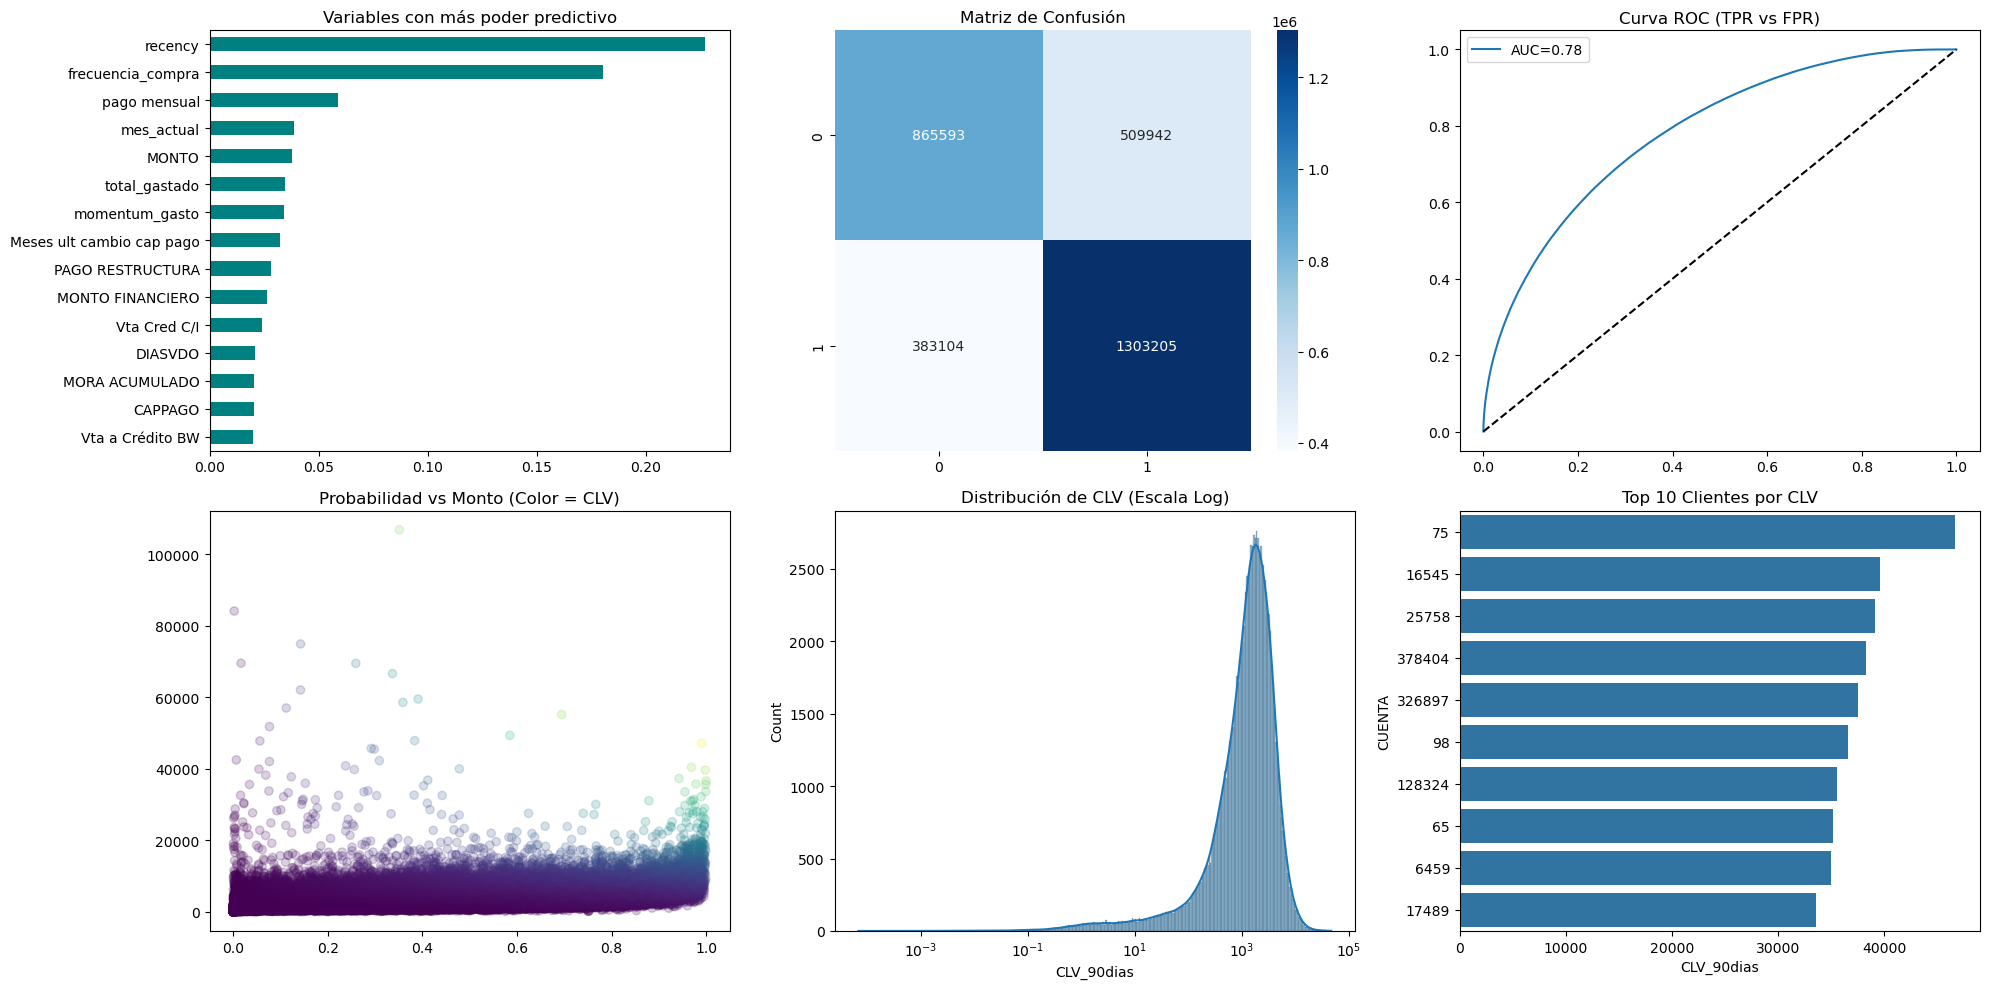

PROCESO FINALIZADO EXITOSAMENTE.

--- DESEMPEÑO DEL MODELO DE CLASIFICACIÓN (DETALLADO) ---
ROC-AUC: 0.783
Average Precision: 0.810
Mejor threshold (F1-max): 0.386

Reporte de Clasificación (Threshold Optimizado):
              precision    recall  f1-score   support

           0       0.78      0.44      0.56   1375535
           1       0.66      0.90      0.76   1686309

    accuracy                           0.69   3061844
   macro avg       0.72      0.67      0.66   3061844
weighted avg       0.72      0.69      0.67   3061844


Matriz de Confusión (Threshold Optimizado):
[[ 599661  775874]
 [ 168430 1517879]]

--- DESEMPEÑO DEL MODELO DE REGRESIÓN (MONTO) ---
RMSE (Error cuadrático): $6826.37
MAE (Error absoluto): $3790.31
Monto Real Promedio: $5525.65
Monto Predicho Promedio: $5394.38

PREDICCIÓN CLV PARA LOS PRÓXIMOS 90 DÍAS:
Total clientes analizados: 105,768
Clientes con alta probabilidad de compra (>50%): 48,425
CLV total esperado (Cartera): $201,849,133.33
CLV promedio po

In [10]:
import polars as pl
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm import tqdm
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings('ignore')

# 1. CARGA SEGURA
print("1. CARGANDO DATOS...")
in_path = r'.\Dataframes LM\Historico-CompraLM.csv'

df_pl = pl.read_csv(
    in_path, 
    encoding='latin-1', 
    infer_schema_length=0, 
    ignore_errors=True,
    null_values=["#", "NA", "null", "", "00/00/0000"]
)

# 2. PARSING DE FECHAS ROBUSTO
print("2. PROCESANDO FECHAS...")
date_cols = [c for c in ['Fecha', 'PRIMERA COMPRA', 'FULTCOMPRA', 'FECNAC'] if c in df_pl.columns]

def robust_date_parsing(df, column):
    # Intentar formatos comunes. strict=False permite que si falla, deje el valor como Nulo en lugar de romper.
    for fmt in ["%d/%m/%Y", "%Y-%m-%d", "%d-%m-%Y", "%m/%d/%Y"]:
        try:
            temp_df = df.with_columns(pl.col(column).str.to_datetime(format=fmt, strict=False))
            # Si logramos parsear al menos una fecha, nos quedamos con este formato
            if temp_df.select(pl.col(column).is_not_null().any()).item():
                return temp_df
        except:
            continue
    return df

for col in date_cols:
    df_pl = robust_date_parsing(df_pl, col)

# Eliminar filas sin fecha de transacción, son vitales para el CLV
df_pl = df_pl.filter(pl.col("Fecha").is_not_null())

# 3. AUDITORÍA DE FEATURES (ANÁLISIS DE LAS 180+ VARIABLES)
print("3. ANALIZANDO RELEVANCIA DE LAS VARIABLES...")

# Variables a ignorar (Identificadores únicos y nombres que no aportan al modelo)
ignore_list = ['CUENTA', 'NOMCLI', 'RFC', 'CURP', 'EMAIL', 'NROCEL', 'CALLE', 'COLONIA', 'NOMPOB', 
               'APPATERNO', 'APMATERNO', 'NOMBRE1', 'NOMBRE2', 'NOMBRE CONYUGE', 'NOMBRE HIJO']

analysis = []
for col in df_pl.columns:
    if col in date_cols or col in ignore_list: continue
    
    # Análisis de calidad
    null_pct = df_pl.select(pl.col(col).is_null().mean()).item() * 100
    unique_n = df_pl.select(pl.col(col).n_unique()).item()
    
    # Scoring de importancia potencial
    score = 0
    if null_pct < 15: score += 10 # Pocos nulos
    if 1 < unique_n < 1000: score += 10 # Cardinalidad sana
    
    # Palabras clave financieras de alto impacto para CLV
    fin_keys = ['MORA', 'SDO', 'PAGO', 'CAPPAGO', 'VTA', 'DIASVDO', 'SALARIO', 'ATRASO', 'CREDITO', 'MONTO']
    if any(k in col.upper() for k in fin_keys): score += 20

    analysis.append({'Variable': col, 'Nulos_%': null_pct, 'Cardinalidad': unique_n, 'Score_Potencial': score})

audit_df = pd.DataFrame(analysis).sort_values(by='Score_Potencial', ascending=False)
audit_df.to_csv(r'.\Modelo LM\Auditoria_Variables_LM.csv', index=False)

# Seleccionamos las mejores 35 variables según la auditoría
top_features = audit_df.head(40)['Variable'].tolist()
if "Vta Total" not in top_features: top_features.append("Vta Total")

print(f"Auditoría terminada. Se seleccionaron {len(top_features)} variables con mayor señal.")

# 4. LIMPIEZA DE DATOS SELECCIONADOS
print("4. LIMPIANDO FEATURES SELECCIONADAS...")
for col in top_features:
    # Quitar símbolos y convertir a numérico lo que sea posible
    df_pl = df_pl.with_columns(
        pl.col(col).str.replace_all(r'[%,]', '').cast(pl.Float64, strict=False).fill_null(0)
    )

# 5. INGENIERÍA DE VARIABLES (RFM + MOMENTUM)
def get_features_advanced(data, fecha_ref):
    fecha_ref = pd.to_datetime(fecha_ref)
    fecha_90d = fecha_ref - timedelta(days=90)
    
    agg_list = [
        pl.col("Vta Total").sum().alias("total_gastado"),
        pl.col("Vta Total").count().alias("frecuencia_compra"),
        ((pl.col("Fecha").max() - pl.col("Fecha").min()).dt.total_days()).alias("recency"),
        pl.lit(fecha_ref.month).alias("mes_actual")
    ]
    
    # Traer el último valor de las top features detectadas
    for f in top_features:
        if f in data.columns and f != "Vta Total":
            agg_list.append(pl.col(f).last().alias(f))

    res = data.group_by("CUENTA").agg(agg_list)
    
    # Momentum (Tendencia de compra reciente)
    mom = data.group_by("CUENTA").agg([
        pl.col("Vta Total").filter(pl.col("Fecha") > fecha_90d).sum().alias("g_rec"),
        pl.col("Vta Total").filter(pl.col("Fecha") <= fecha_90d).sum().alias("g_ant")
    ]).with_columns((pl.col("g_rec") / (pl.col("g_ant") + 1)).alias("momentum_gasto"))
    
    return res.join(mom.select(["CUENTA", "momentum_gasto"]), on="CUENTA", how="left").fill_null(0)

# 6. GENERACIÓN DE VENTANAS (LOGICA CORREGIDA PARA EVITAR INDEXERROR)
print("5. PROCESANDO VENTANAS TEMPORALES...")
df_pl = df_pl.sort(["Fecha"])
unique_dates = df_pl.select("Fecha").unique().sort("Fecha").to_series().to_list()

# Definimos los saltos en días
OBS_DAYS = 270
PRED_DAYS = 90

# Filtramos fechas de inicio que permitan tener una ventana completa
start_date_limit = unique_dates[-1] - timedelta(days=OBS_DAYS + PRED_DAYS)
possible_starts = [d for d in unique_dates if d <= start_date_limit]

# Número de ventanas a generar
WINDOWS = 150

# Generamos 100 ventanas distribuidas en el tiempo
n_windows = min(WINDOWS, len(possible_starts))
indices = np.linspace(0, len(possible_starts) - 1, n_windows, dtype=int)

all_windows = []
for idx in tqdm(indices):
    start_obs = possible_starts[idx]
    end_obs = start_obs + timedelta(days=OBS_DAYS)
    end_pred = end_obs + timedelta(days=PRED_DAYS)
    
    # Filtros por fecha real
    obs = df_pl.filter((pl.col("Fecha") >= start_obs) & (pl.col("Fecha") < end_obs))
    pred = df_pl.filter((pl.col("Fecha") >= end_obs) & (pl.col("Fecha") < end_pred))
    
    if obs.is_empty() or pred.is_empty(): continue
    
    X_w = get_features_advanced(obs, end_obs)
    y_w = pred.group_by("CUENTA").agg(pl.col("Vta Total").sum().alias("target_monto"))
    
    win = X_w.join(y_w, on="CUENTA", how="left").fill_null(0)
    win = win.with_columns((pl.col("target_monto") > 0).cast(pl.Int32).alias("target_class"))
    all_windows.append(win)

final_df = pl.concat(all_windows).to_pandas()

# 7. ENTRENAMIENTO (Aumentamos un poco la complejidad para captar más patrones)
print("6. ENTRENANDO MODELOS...")
X = final_df.drop(['CUENTA', 'target_class', 'target_monto'], axis=1)

variables_peligrosas = ['SDO', 'PAGO', 'Semanas de Atraso', '% Uso Cap pago', 'A CREDITO']
variables_a_eliminar = [v for v in variables_peligrosas if v in X.columns]
X = X.drop(columns=variables_a_eliminar)

y_c, y_m = final_df['target_class'], final_df['target_monto']

for col in X.select_dtypes(['object', 'string']).columns:
    X[col] = pd.factorize(X[col])[0]

X_train, X_test, yc_train, yc_test, ym_train, ym_test = train_test_split(X, y_c, y_m, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Ajustamos scale_pos_weight: Si tienes pocos compradores, aumenta este número (ej. 20 o 25) 
# para que el modelo se esfuerce más en encontrarlos.
base_clf = xgb.XGBClassifier(
    n_estimators=250, 
    max_depth=6, 
    tree_method='hist', 
    n_jobs=-1, 
    scale_pos_weight=20, 
    eval_metric='aucpr'
)

calibrated_clf = CalibratedClassifierCV(base_clf, method='isotonic', cv=3)

calibrated_clf.fit(X_train_s, yc_train)

clf = calibrated_clf

reg = xgb.XGBRegressor(n_estimators=250, tree_method='hist', n_jobs=-1, objective='reg:gamma')
reg.fit(X_train_s[yc_train == 1], ym_train[yc_train == 1])

# 8. PREDICCIÓN FINAL (UMBRAL MÁS AGRESIVO PARA MARKETING)
print("7. CALCULANDO CLV PARA TODOS LOS CLIENTES...")
max_f = df_pl.select(pl.col("Fecha").max()).to_series()[0]
actual_obs = df_pl.filter(pl.col("Fecha") >= (max_f - timedelta(days=OBS_DAYS)))

X_act_pd = get_features_advanced(actual_obs, max_f).to_pandas()
X_act_clean = X_act_pd.drop('CUENTA', axis=1)

for col in X_act_clean.select_dtypes(['object', 'string']).columns:
    X_act_clean[col] = pd.factorize(X_act_clean[col])[0]
X_act_clean = X_act_clean[X.columns]

X_act_s = scaler.transform(X_act_clean)
probs = clf.predict_proba(X_act_s)[:, 1]
montos = reg.predict(X_act_s)

preds = pd.DataFrame({
    'CUENTA': X_act_pd['CUENTA'],
    'Probabilidad_Compra_90d': probs,
    'Monto_Esperado_90d': montos,
    'CLV_90dias': probs * montos
})

# Universo Total
todas_cuentas = df_pl.select(pl.col("CUENTA").unique()).to_series().to_list()
df_final = pd.DataFrame({'CUENTA': todas_cuentas}).merge(preds, on='CUENTA', how='left').fillna(0)

y_proba_test_cal = clf.predict_proba(X_test_s)[:, 1]
prec, rec, thrs = precision_recall_curve(yc_test, y_proba_test_cal)
f1_s = (2 * prec * rec) / (prec + rec + 1e-10)
umbral_f1 = thrs[np.argmax(f1_s)]
df_final['Umbral_Optimo_CLV'] = umbral_f1


df_final.to_csv(r'.\Dataframes LM\predicciones_clv_90dias.csv', index=False, encoding='utf-8-sig')

# 9. DASHBOARD FINAL
print("8. GENERANDO DASHBOARD...")
plt.figure(figsize=(20, 10))

# Importancia de Variables (Responde tu duda de qué variables son importantes)
plt.subplot(2, 3, 1)
# Extraemos y promediamos las importancias de los estimadores internos
importances = np.mean([
    est.estimator.feature_importances_ for est in clf.calibrated_classifiers_
], axis=0)

pd.Series(importances, index=X.columns).sort_values().tail(15).plot(kind='barh', color='teal')
plt.title('Variables con más poder predictivo')

# Matriz de Confusión
plt.subplot(2, 3, 2)
sns.heatmap(confusion_matrix(yc_test, clf.predict(X_test_s)), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')

# Curva ROC
fpr, tpr, _ = roc_curve(yc_test, clf.predict_proba(X_test_s)[:, 1])
plt.subplot(2, 3, 3)
plt.plot(fpr, tpr, label=f'AUC={auc(fpr, tpr):.2f}'); plt.plot([0,1],[0,1],'k--'); plt.legend(); plt.title('Curva ROC (TPR vs FPR)')

# Probabilidad vs Monto
plt.subplot(2, 3, 4)
plt.scatter(preds['Probabilidad_Compra_90d'], preds['Monto_Esperado_90d'], alpha=0.2, c=preds['CLV_90dias'], cmap='viridis')
plt.title('Probabilidad vs Monto (Color = CLV)')

# Distribución CLV
plt.subplot(2, 3, 5)
sns.histplot(df_final[df_final['CLV_90dias']>0]['CLV_90dias'], log_scale=True, kde=True)
plt.title('Distribución de CLV (Escala Log)')

# Top 10 Clientes
plt.subplot(2, 3, 6)
top10 = df_final.nlargest(10, 'CLV_90dias')
sns.barplot(x='CLV_90dias', y=top10['CUENTA'].astype(str), data=top10)
plt.title('Top 10 Clientes por CLV')

plt.tight_layout()
plt.show()

print("PROCESO FINALIZADO EXITOSAMENTE.")


from sklearn.metrics import classification_report, average_precision_score, precision_recall_curve, roc_auc_score, mean_squared_error, mean_absolute_error

# 10. REPORTE DETALLADO DE MÉTRICAS
print("\n" + "="*50)
print("--- DESEMPEÑO DEL MODELO DE CLASIFICACIÓN (DETALLADO) ---")
print("="*50)

# Obtener probabilidades
y_proba_test = clf.predict_proba(X_test_s)[:, 1]

# 1. Métricas Globales
auc_score = roc_auc_score(yc_test, y_proba_test)
ap_score = average_precision_score(yc_test, y_proba_test)

# 2. Threshold Optimizado
precision, recall, thresholds = precision_recall_curve(yc_test, y_proba_test)
f1_scores = (2 * precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
y_pred_opt = (y_proba_test >= best_threshold).astype(int)

# 3. Imprimir Resultados
print(f"ROC-AUC: {auc_score:.3f}")
print(f"Average Precision: {ap_score:.3f}")
print(f"Mejor threshold (F1-max): {best_threshold:.3f}")
print("\nReporte de Clasificación (Threshold Optimizado):")
print(classification_report(yc_test, y_pred_opt))

print("\nMatriz de Confusión (Threshold Optimizado):")
print(confusion_matrix(yc_test, y_pred_opt))

# 4. Evaluación de Regresión (Solo reales compradores)
print("\n" + "="*50)
print("--- DESEMPEÑO DEL MODELO DE REGRESIÓN (MONTO) ---")
print("="*50)

actual_buyers_mask = (yc_test == 1)
if actual_buyers_mask.any():
    y_reg_pred_all = reg.predict(X_test_s)
    y_reg_pred_buyers = y_reg_pred_all[actual_buyers_mask]
    y_reg_actual_buyers = ym_test[actual_buyers_mask]
    
    rmse = np.sqrt(mean_squared_error(y_reg_actual_buyers, y_reg_pred_buyers))
    mae = mean_absolute_error(y_reg_actual_buyers, y_reg_pred_buyers)
    
    print(f"RMSE (Error cuadrático): ${rmse:.2f}")
    print(f"MAE (Error absoluto): ${mae:.2f}")
    print(f"Monto Real Promedio: ${y_reg_actual_buyers.mean():.2f}")
    print(f"Monto Predicho Promedio: ${y_reg_pred_buyers.mean():.2f}")
else:
    print("No hay suficientes compradores en el set de prueba para evaluar el monto.")
    
# 11. RESUMEN DE PREDICCIONES FUTURAS
print("\n" + "="*50)
print(f"PREDICCIÓN CLV PARA LOS PRÓXIMOS 90 DÍAS:")
print("="*50)

# Usamos las columnas específicas del DataFrame 'preds'
# Nota: Si tu variable se llama 'df_final' o 'preds_activos', asegúrate de usar ese nombre
total_clientes = len(preds)
# Contamos cuántos tienen probabilidad > 0.5 en la columna específica
compradores_esperados = (preds['Probabilidad_Compra_90d'] > 0.5).sum()
clv_total = preds['CLV_90dias'].sum()
clv_promedio = preds['CLV_90dias'].mean()

print(f"Total clientes analizados: {total_clientes:,}")
print(f"Clientes con alta probabilidad de compra (>50%): {compradores_esperados:,}")
print(f"CLV total esperado (Cartera): ${clv_total:,.2f}")
print(f"CLV promedio por cliente: ${clv_promedio:,.2f}")

clientes_prob_cero = preds[preds['Probabilidad_Compra_90d'] == 0]
casos_latentes = clientes_prob_cero[clientes_prob_cero['Monto_Esperado_90d'] > 0]
monto_promedio_latente = casos_latentes['Monto_Esperado_90d'].mean() if not casos_latentes.empty else 0

print("\n--- ANÁLISIS DE VALOR LATENTE (PROB 0% PERO MONTO > 0) ---")
print(f"Clientes con Probabilidad 0%: {len(clientes_prob_cero):,}")
print(f"De ellos, con monto esperado positivo: {len(casos_latentes):,}")
print(f"Monto promedio si logras reactivarlos: ${monto_promedio_latente:,.2f}")


# Extra: Valor de los clientes que NO son cero
clientes_con_valor = preds[preds['CLV_90dias'] > 0]
print(f"CLV promedio (solo clientes con potencial): ${clientes_con_valor['CLV_90dias'].mean():,.2f}")

# Modelo LTV EB

### Analisis de Cohorte

Cargando datos para análisis de cohortes...
Identificando primera compra de cada cliente...
Calculando cohortes mensuales...
Creando matriz de cohortes...
Calculando tasas de retención...
Analizando tasas de recompra...
Generando visualizaciones...


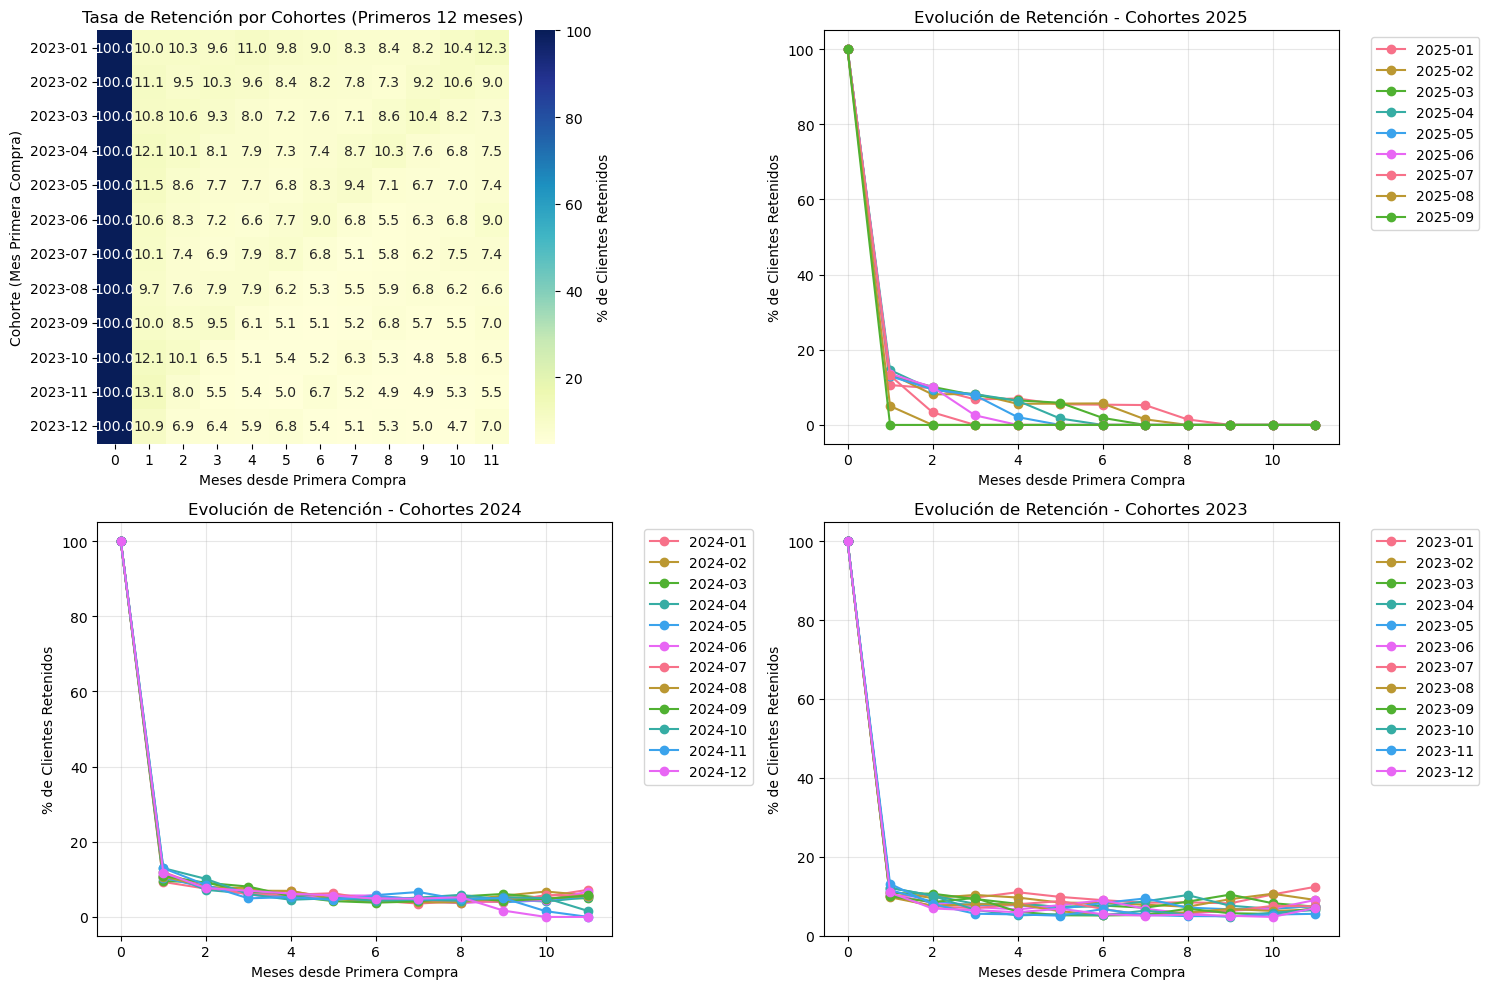

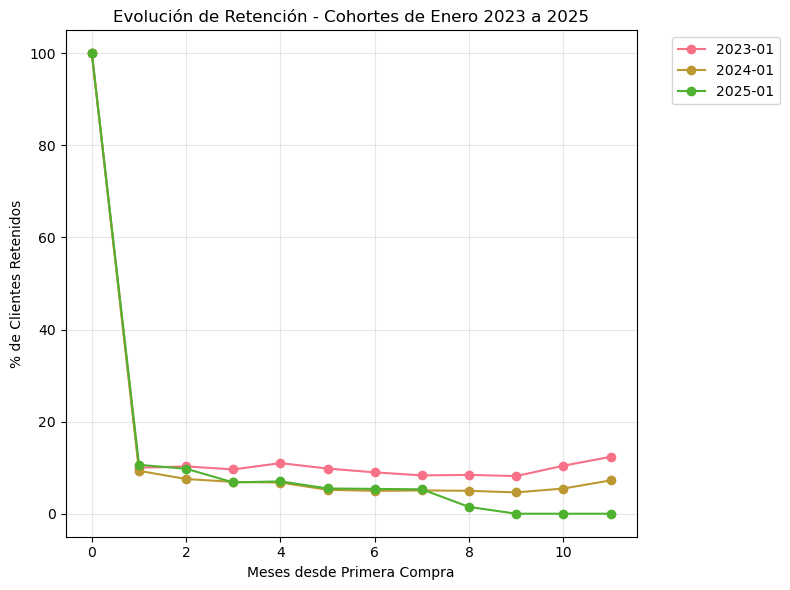

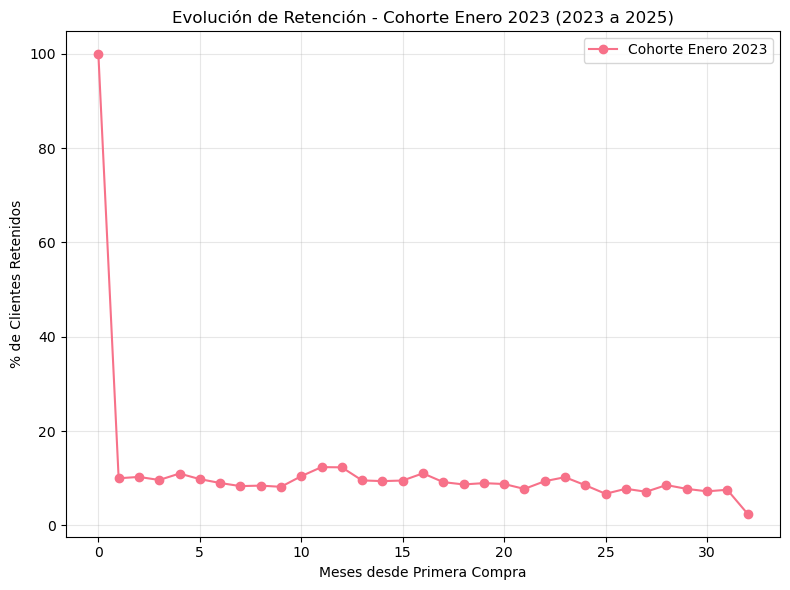


ANÁLISIS DE COHORTES - ESTADÍSTICAS PRINCIPALES

1. TASA DE RETENCIÓN PROMEDIO:
   - A 3 meses: 6.5%
   - A 6 meses: 4.7%
   - A 12 meses: 5.9%

2. TASA DE RECOMPRA PROMEDIO:
   - Mes 1: 97.0%
   - Mes 3: 90.9%
   - Mes 6: 81.8%

3. COHORTES CON MEJOR DESEMPEÑO:
   - Mejor retención a 3 meses: 2023-02
   - Mejor retención a 6 meses: 2023-01

4. TENDENCIA TEMPORAL:
   - Cambio en retención a 3 meses: -9.6%

5. ESTADÍSTICAS DE CLIENTES:
   - Total de clientes únicos: 294,163
   - Total de cohortes analizadas: 33
   - Tamaño promedio de cohorte: 8914 clientes
   - Cohorte más grande: 19,960.0 clientes (2023-01)
   - Cohorte más pequeña: 1,220.0 clientes (2025-09)


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")

# Cargar datos
print("Cargando datos para análisis de cohortes...")
df = pd.read_csv(r'.\Dataframes EB\Historico-CompraEB.csv', encoding='latin-1', low_memory=False)

# Preprocesamiento básico de fechas
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
df = df.dropna(subset=['Fecha', 'CUENTA'])

# Ordenar por fecha
df = df.sort_values(['CUENTA', 'Fecha'])

# 1. IDENTIFICAR PRIMERA COMPRA DE CADA CLIENTE
print("Identificando primera compra de cada cliente...")
primera_compra = df.groupby('CUENTA')['Fecha'].min().reset_index()
primera_compra.rename(columns={'Fecha': 'Primera_Compra'}, inplace=True)

# Unir con datos originales
df_cohort = df.merge(primera_compra, on='CUENTA')

# 2. CALCULAR COHORTES POR MES DE PRIMERA COMPRA
print("Calculando cohortes mensuales...")
df_cohort['Cohort_Mes'] = df_cohort['Primera_Compra'].dt.to_period('M')
df_cohort['Mes_Compra'] = df_cohort['Fecha'].dt.to_period('M')

# 3. CALCULAR NÚMERO DE MESES DESDE PRIMERA COMPRA
df_cohort['Meses_Desde_Primera'] = (
    (df_cohort['Mes_Compra'].dt.year - df_cohort['Cohort_Mes'].dt.year) * 12 +
    (df_cohort['Mes_Compra'].dt.month - df_cohort['Cohort_Mes'].dt.month)
)

# 4. MATRIZ DE COHORTES - CLIENTES ACTIVOS POR MES
print("Creando matriz de cohortes...")
cohort_data = df_cohort.groupby(['Cohort_Mes', 'Meses_Desde_Primera'])['CUENTA'].nunique().reset_index()
cohort_pivot = cohort_data.pivot_table(index='Cohort_Mes', 
                                      columns='Meses_Desde_Primera', 
                                      values='CUENTA', 
                                      fill_value=0)

# 5. CALCULAR TASA DE RETENCIÓN
print("Calculando tasas de retención...")
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100

# 6. ANÁLISIS DE RECOMPRA
print("Analizando tasas de recompra...")
# Identificar si un cliente recompró en cada mes
recompra_data = df_cohort.groupby(['CUENTA', 'Mes_Compra']).size().reset_index()
recompra_data['Recompro'] = 1

# Calcular tasa de recompra por cohorte
recompra_cohort = df_cohort.merge(recompra_data, on=['CUENTA', 'Mes_Compra'], how='left')
recompra_cohort['Recompro'] = recompra_cohort['Recompro'].fillna(0)

tasa_recompra = recompra_cohort.groupby(['Cohort_Mes', 'Meses_Desde_Primera'])['Recompro'].mean().reset_index()
tasa_recompra_pivot = tasa_recompra.pivot_table(index='Cohort_Mes', 
                                               columns='Meses_Desde_Primera', 
                                               values='Recompro', 
                                               fill_value=0) * 100

# 7. VISUALIZACIONES
print("Generando visualizaciones...")

# Heatmap de Retención
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.heatmap(retention_matrix.iloc[:12, :12], 
            annot=True, fmt='.1f', cmap='YlGnBu', 
            cbar_kws={'label': '% de Clientes Retenidos'})
plt.title('Tasa de Retención por Cohortes (Primeros 12 meses)')
plt.ylabel('Cohorte (Mes Primera Compra)')
plt.xlabel('Meses desde Primera Compra')

 
# Evolución de la Retención
plt.subplot(2, 2, 2)
cohortes_2025 = retention_matrix[retention_matrix.index.astype(str).str.startswith("2025-")]
for cohorte in cohortes_2025.index:
    plt.plot(cohortes_2025.columns[:12], 
             cohortes_2025.loc[cohorte].values[:12], 
             marker='o', label=str(cohorte))
plt.title('Evolución de Retención - Cohortes 2025')
plt.xlabel('Meses desde Primera Compra')
plt.ylabel('% de Clientes Retenidos')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Evolución de la Retención - Cohortes de 2024
plt.subplot(2, 2, 3)  # <- nueva posición en la cuadrícula de 2x2
cohortes_2024 = retention_matrix[retention_matrix.index.astype(str).str.startswith("2024")]
for cohorte in cohortes_2024.index:
    plt.plot(cohortes_2024.columns[:12], 
             cohortes_2024.loc[cohorte].values[:12], 
             marker='o', label=str(cohorte))
plt.title('Evolución de Retención - Cohortes 2024')
plt.xlabel('Meses desde Primera Compra')
plt.ylabel('% de Clientes Retenidos')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Evolución de la Retención - Cohortes de 2023 (desde enero)
plt.subplot(2, 2, 4)  # posición en cuadrícula 2x2
cohortes_2023 = retention_matrix[retention_matrix.index.astype(str).str.startswith("2023-")]
cohortes_2023 = cohortes_2023[cohortes_2023.index >= "2023-01"]  # asegura desde enero
for cohorte in cohortes_2023.index:
    plt.plot(cohortes_2023.columns[:12], 
             cohortes_2023.loc[cohorte].values[:12], 
             marker='o', label=str(cohorte))
plt.title('Evolución de Retención - Cohortes 2023')
plt.xlabel('Meses desde Primera Compra')
plt.ylabel('% de Clientes Retenidos')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

 
plt.tight_layout()
plt.show()
 
# Evolución de Retención - Cohortes de Enero (2023 a 2025)
plt.figure(figsize=(8,6))
cohortes_enero = retention_matrix[retention_matrix.index.astype(str).str.endswith("-01")]
cohortes_enero = cohortes_enero.loc["2023-01":"2025-12"]  # filtrar rango

for cohorte in cohortes_enero.index:
    plt.plot(cohortes_enero.columns[:12], 
             cohortes_enero.loc[cohorte].values[:12], 
             marker='o', label=str(cohorte))

plt.title('Evolución de Retención - Cohortes de Enero 2023 a 2025')
plt.xlabel('Meses desde Primera Compra')
plt.ylabel('% de Clientes Retenidos')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.tight_layout()
plt.show()

# Evolución de la cohorte de Enero 2023 (todo el periodo disponible)
plt.figure(figsize=(8,6))

cohorte_2023_enero = retention_matrix.loc["2023-01"]

plt.plot(cohorte_2023_enero.index, 
         cohorte_2023_enero.values, 
         marker='o', label="Cohorte Enero 2023")

plt.title('Evolución de Retención - Cohorte Enero 2023 (2023 a 2025)')
plt.xlabel('Meses desde Primera Compra')
plt.ylabel('% de Clientes Retenidos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8. ESTADÍSTICAS RESUMEN
print("\n" + "="*50)
print("ANÁLISIS DE COHORTES - ESTADÍSTICAS PRINCIPALES")
print("="*50)

# Tasa de retención promedio a 3, 6 y 12 meses
retencion_3meses = retention_matrix[3].mean() if 3 in retention_matrix.columns else 0
retencion_6meses = retention_matrix[6].mean() if 6 in retention_matrix.columns else 0
retencion_12meses = retention_matrix[12].mean() if 12 in retention_matrix.columns else 0

print(f"\n1. TASA DE RETENCIÓN PROMEDIO:")
print(f"   - A 3 meses: {retencion_3meses:.1f}%")
print(f"   - A 6 meses: {retencion_6meses:.1f}%")
print(f"   - A 12 meses: {retencion_12meses:.1f}%")

# Tasa de recompra promedio
if not tasa_recompra_pivot.empty:
    recompra_promedio_mes1 = tasa_recompra_pivot[1].mean() if 1 in tasa_recompra_pivot.columns else 0
    recompra_promedio_mes3 = tasa_recompra_pivot[3].mean() if 3 in tasa_recompra_pivot.columns else 0
    recompra_promedio_mes6 = tasa_recompra_pivot[6].mean() if 6 in tasa_recompra_pivot.columns else 0
    
    print(f"\n2. TASA DE RECOMPRA PROMEDIO:")
    print(f"   - Mes 1: {recompra_promedio_mes1:.1f}%")
    print(f"   - Mes 3: {recompra_promedio_mes3:.1f}%")
    print(f"   - Mes 6: {recompra_promedio_mes6:.1f}%")

# Cohortes con mejor desempeño
if not retention_matrix.empty:
    mejor_cohorte_3meses = retention_matrix[3].idxmax() if 3 in retention_matrix.columns else "N/A"
    mejor_cohorte_6meses = retention_matrix[6].idxmax() if 6 in retention_matrix.columns else "N/A"
    
    print(f"\n3. COHORTES CON MEJOR DESEMPEÑO:")
    print(f"   - Mejor retención a 3 meses: {mejor_cohorte_3meses}")
    print(f"   - Mejor retención a 6 meses: {mejor_cohorte_6meses}")

# Tendencias temporales
if len(retention_matrix) > 1:
    tendencia_retencion = retention_matrix[3].iloc[-1] - retention_matrix[3].iloc[0] if 3 in retention_matrix.columns else 0
    print(f"\n4. TENDENCIA TEMPORAL:")
    print(f"   - Cambio en retención a 3 meses: {tendencia_retencion:+.1f}%")

# Clientes por cohorte
print(f"\n5. ESTADÍSTICAS DE CLIENTES:")
print(f"   - Total de clientes únicos: {df_cohort['CUENTA'].nunique():,}")
print(f"   - Total de cohortes analizadas: {len(cohort_size)}")
print(f"   - Tamaño promedio de cohorte: {cohort_size.mean():.0f} clientes")
print(f"   - Cohorte más grande: {cohort_size.max():,} clientes ({cohort_size.idxmax()})")
print(f"   - Cohorte más pequeña: {cohort_size.min():,} clientes ({cohort_size.idxmin()})")



### Modelo ML (LTV)

1. CARGANDO DATOS...
2. PROCESANDO FECHAS...
3. ANALIZANDO RELEVANCIA DE LAS VARIABLES...
Auditoría terminada. Se seleccionaron 45 variables con mayor señal.
4. LIMPIANDO FEATURES SELECCIONADAS...
5. PROCESANDO VENTANAS TEMPORALES...


100%|██████████| 150/150 [00:35<00:00,  4.25it/s]


6. ENTRENANDO MODELOS...
7. CALCULANDO CLV PARA TODOS LOS CLIENTES...
8. GENERANDO DASHBOARD...


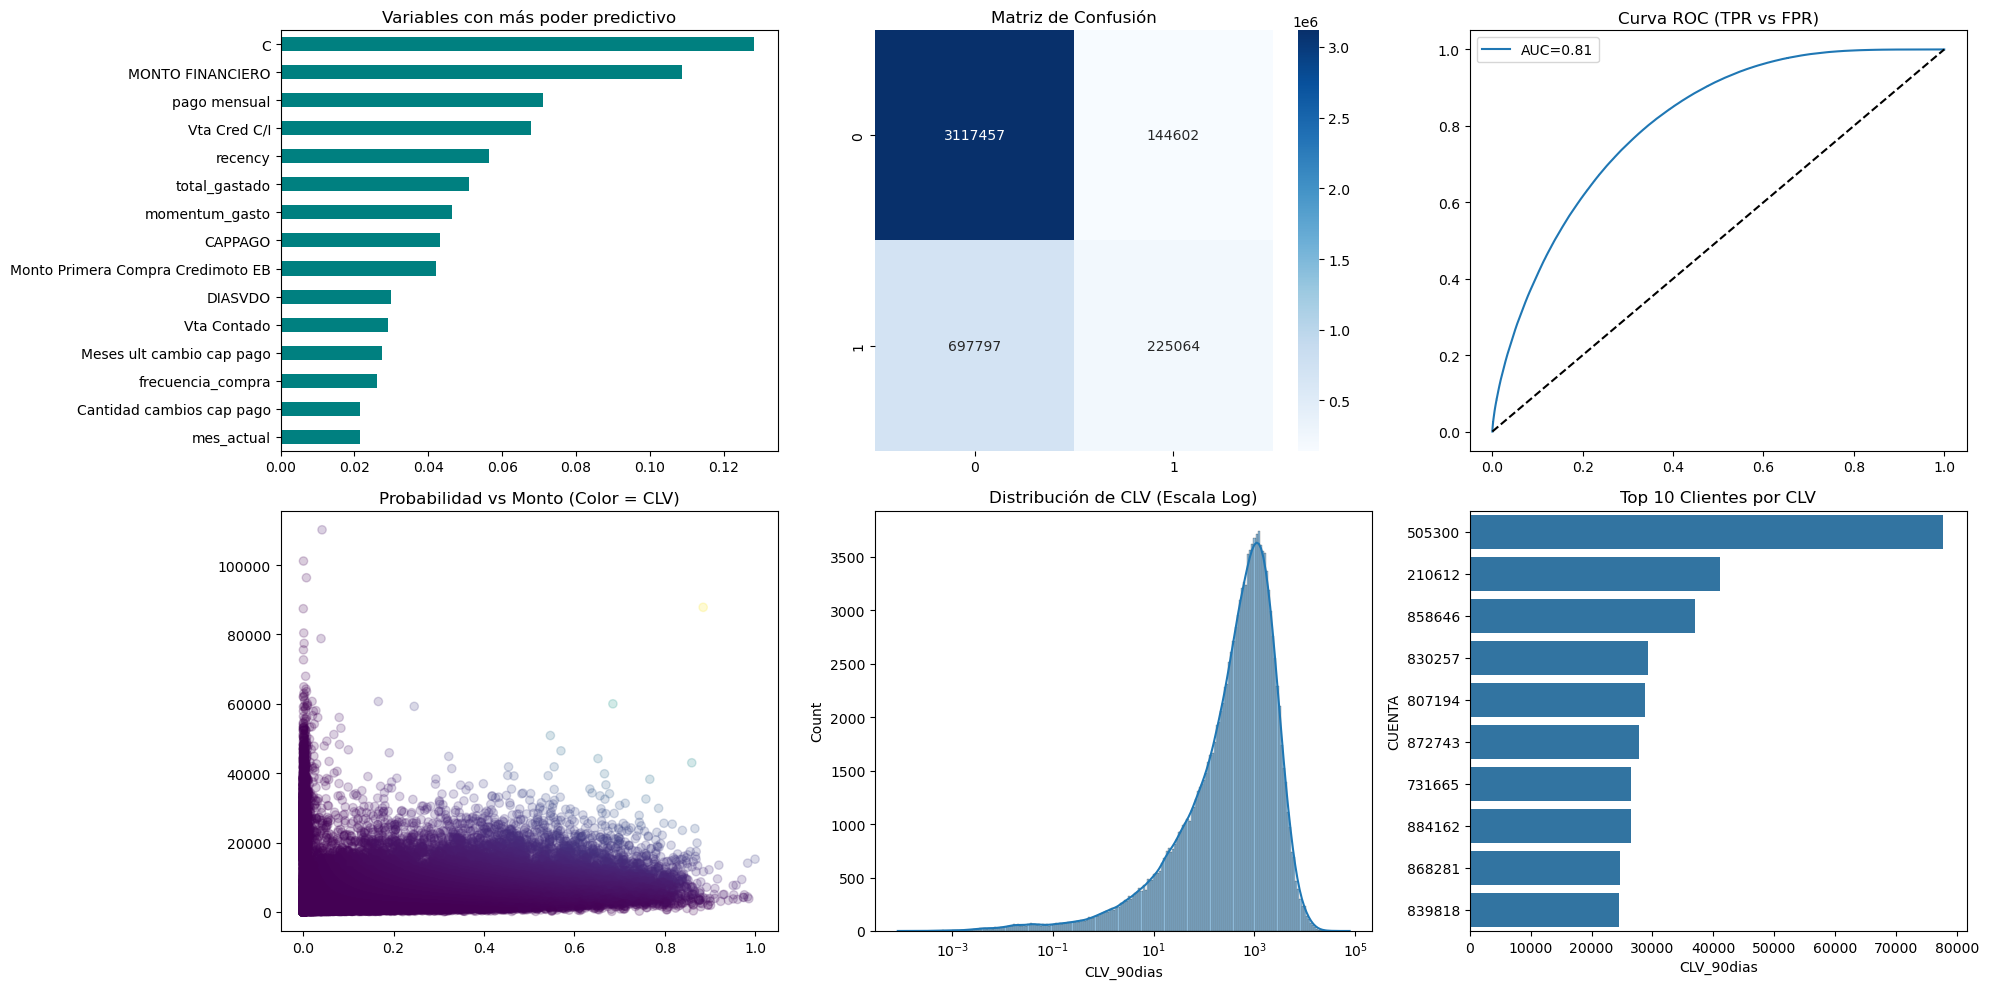

PROCESO FINALIZADO EXITOSAMENTE.

--- DESEMPEÑO DEL MODELO DE CLASIFICACIÓN (DETALLADO) ---
ROC-AUC: 0.806
Average Precision: 0.518
Mejor threshold (F1-max): 0.276

Reporte de Clasificación (Threshold Optimizado):
              precision    recall  f1-score   support

           0       0.90      0.74      0.81   3262059
           1       0.44      0.70      0.54    922861

    accuracy                           0.73   4184920
   macro avg       0.67      0.72      0.68   4184920
weighted avg       0.80      0.73      0.75   4184920


Matriz de Confusión (Threshold Optimizado):
[[2425310  836749]
 [ 276849  646012]]

--- DESEMPEÑO DEL MODELO DE REGRESIÓN (MONTO) ---
RMSE (Error cuadrático): $5103.34
MAE (Error absoluto): $3294.68
Monto Real Promedio: $5777.07
Monto Predicho Promedio: $5638.27

PREDICCIÓN CLV PARA LOS PRÓXIMOS 90 DÍAS:
Total clientes analizados: 145,041
Clientes con alta probabilidad de compra (>50%): 11,301
CLV total esperado (Cartera): $155,673,071.92
CLV promedio po

In [8]:
import polars as pl
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm import tqdm
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings('ignore')

# 1. CARGA SEGURA
print("1. CARGANDO DATOS...")
in_path = r'.\Dataframes EB\Historico-CompraEB.csv'

df_pl = pl.read_csv(
    in_path, 
    encoding='latin-1', 
    infer_schema_length=0, 
    ignore_errors=True,
    null_values=["#", "NA", "null", "", "00/00/0000"]
)

# 2. PARSING DE FECHAS ROBUSTO
print("2. PROCESANDO FECHAS...")
date_cols = [c for c in ['Fecha', 'PRIMERA COMPRA', 'FULTCOMPRA', 'FECNAC'] if c in df_pl.columns]

def robust_date_parsing(df, column):
    # Intentar formatos comunes. strict=False permite que si falla, deje el valor como Nulo en lugar de romper.
    for fmt in ["%d/%m/%Y", "%Y-%m-%d", "%d-%m-%Y", "%m/%d/%Y"]:
        try:
            temp_df = df.with_columns(pl.col(column).str.to_datetime(format=fmt, strict=False))
            # Si logramos parsear al menos una fecha, nos quedamos con este formato
            if temp_df.select(pl.col(column).is_not_null().any()).item():
                return temp_df
        except:
            continue
    return df

for col in date_cols:
    df_pl = robust_date_parsing(df_pl, col)

# Eliminar filas sin fecha de transacción, son vitales para el CLV
df_pl = df_pl.filter(pl.col("Fecha").is_not_null())

# 3. AUDITORÍA DE FEATURES (ANÁLISIS DE LAS 180+ VARIABLES)
print("3. ANALIZANDO RELEVANCIA DE LAS VARIABLES...")

# Variables a ignorar (Identificadores únicos y nombres que no aportan al modelo)
ignore_list = ['CUENTA', 'NOMCLI', 'RFC', 'CURP', 'EMAIL', 'NROCEL', 'CALLE', 'COLONIA', 'NOMPOB', 
               'APPATERNO', 'APMATERNO', 'NOMBRE1', 'NOMBRE2', 'NOMBRE CONYUGE', 'NOMBRE HIJO']

analysis = []
for col in df_pl.columns:
    if col in date_cols or col in ignore_list: continue
    
    # Análisis de calidad
    null_pct = df_pl.select(pl.col(col).is_null().mean()).item() * 100
    unique_n = df_pl.select(pl.col(col).n_unique()).item()
    
    # Scoring de importancia potencial
    score = 0
    if null_pct < 15: score += 10 # Pocos nulos
    if 1 < unique_n < 1000: score += 10 # Cardinalidad sana
    
    # Palabras clave financieras de alto impacto para CLV
    fin_keys = ['MORA', 'SDO', 'PAGO', 'CAPPAGO', 'VTA', 'DIASVDO', 'SALARIO', 'ATRASO', 'CREDITO', 'MONTO']
    if any(k in col.upper() for k in fin_keys): score += 20

    analysis.append({'Variable': col, 'Nulos_%': null_pct, 'Cardinalidad': unique_n, 'Score_Potencial': score})

audit_df = pd.DataFrame(analysis).sort_values(by='Score_Potencial', ascending=False)
audit_df.to_csv(r'.\Modelo EB\Auditoria_Variables_EB.csv', index=False)

# Seleccionamos las mejores 35 variables según la auditoría
top_features = audit_df.head(45)['Variable'].tolist()
if "Vta Total" not in top_features: top_features.append("Vta Total")

print(f"Auditoría terminada. Se seleccionaron {len(top_features)} variables con mayor señal.")

# 4. LIMPIEZA DE DATOS SELECCIONADOS
print("4. LIMPIANDO FEATURES SELECCIONADAS...")
for col in top_features:
    # Quitar símbolos y convertir a numérico lo que sea posible
    df_pl = df_pl.with_columns(
        pl.col(col).str.replace_all(r'[%,]', '').cast(pl.Float64, strict=False).fill_null(0)
    )

# 5. INGENIERÍA DE VARIABLES (RFM + MOMENTUM)
def get_features_advanced(data, fecha_ref):
    fecha_ref = pd.to_datetime(fecha_ref)
    fecha_90d = fecha_ref - timedelta(days=90)
    
    agg_list = [
        pl.col("Vta Total").sum().alias("total_gastado"),
        pl.col("Vta Total").count().alias("frecuencia_compra"),
        ((pl.col("Fecha").max() - pl.col("Fecha").min()).dt.total_days()).alias("recency"),
        pl.lit(fecha_ref.month).alias("mes_actual")
    ]
    
    # Traer el último valor de las top features detectadas
    for f in top_features:
        if f in data.columns and f != "Vta Total":
            agg_list.append(pl.col(f).last().alias(f))

    res = data.group_by("CUENTA").agg(agg_list)
    res = res.with_columns([
    (pl.col("mes_actual").is_in([5, 11, 12])).cast(pl.Int32).alias("es_temporada_alta")
        ])

    # Momentum (Tendencia de compra reciente)
    mom = data.group_by("CUENTA").agg([
        pl.col("Vta Total").filter(pl.col("Fecha") > fecha_90d).sum().alias("g_rec"),
        pl.col("Vta Total").filter(pl.col("Fecha") <= fecha_90d).sum().alias("g_ant")
    ]).with_columns((pl.col("g_rec") / (pl.col("g_ant") + 1)).alias("momentum_gasto"))
    
    return res.join(mom.select(["CUENTA", "momentum_gasto"]), on="CUENTA", how="left").fill_null(0)

# 6. GENERACIÓN DE VENTANAS (LOGICA CORREGIDA PARA EVITAR INDEXERROR)
print("5. PROCESANDO VENTANAS TEMPORALES...")
df_pl = df_pl.sort(["Fecha"])
unique_dates = df_pl.select("Fecha").unique().sort("Fecha").to_series().to_list()

# Definimos los saltos en días
OBS_DAYS = 270
PRED_DAYS = 90

# Filtramos fechas de inicio que permitan tener una ventana completa
start_date_limit = unique_dates[-1] - timedelta(days=OBS_DAYS + PRED_DAYS)
possible_starts = [d for d in unique_dates if d <= start_date_limit]

# Número de ventanas a generar
WINDOWS = 150

# Generamos 100 ventanas distribuidas en el tiempo
n_windows = min(WINDOWS, len(possible_starts))
indices = np.linspace(0, len(possible_starts) - 1, n_windows, dtype=int)

all_windows = []
for idx in tqdm(indices):
    start_obs = possible_starts[idx]
    end_obs = start_obs + timedelta(days=OBS_DAYS)
    end_pred = end_obs + timedelta(days=PRED_DAYS)
    
    # Filtros por fecha real
    obs = df_pl.filter((pl.col("Fecha") >= start_obs) & (pl.col("Fecha") < end_obs))
    pred = df_pl.filter((pl.col("Fecha") >= end_obs) & (pl.col("Fecha") < end_pred))
    
    if obs.is_empty() or pred.is_empty(): continue
    
    X_w = get_features_advanced(obs, end_obs)
    y_w = pred.group_by("CUENTA").agg(pl.col("Vta Total").sum().alias("target_monto"))
    
    win = X_w.join(y_w, on="CUENTA", how="left").fill_null(0)
    win = win.with_columns((pl.col("target_monto") > 0).cast(pl.Int32).alias("target_class"))
    all_windows.append(win)

final_df = pl.concat(all_windows).to_pandas()

# 7. ENTRENAMIENTO (Aumentamos un poco la complejidad para captar más patrones)
print("6. ENTRENANDO MODELOS...")
X = final_df.drop(['CUENTA', 'target_class', 'target_monto'], axis=1)

variables_peligrosas = ['SDO', 'PAGO', 'Semanas de Atraso', '% Uso Cap pago', 'A CREDITO']
variables_a_eliminar = [v for v in variables_peligrosas if v in X.columns]
X = X.drop(columns=variables_a_eliminar)

y_c, y_m = final_df['target_class'], final_df['target_monto']

for col in X.select_dtypes(['object', 'string']).columns:
    X[col] = pd.factorize(X[col])[0]

X_train, X_test, yc_train, yc_test, ym_train, ym_test = train_test_split(X, y_c, y_m, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Ajustamos scale_pos_weight: Si tienes pocos compradores, aumenta este número (ej. 20 o 25) 
# para que el modelo se esfuerce más en encontrarlos.
base_clf = xgb.XGBClassifier(
    n_estimators=300, 
    max_depth=6, 
    tree_method='hist', 
    n_jobs=-1, 
    scale_pos_weight=23, 
    eval_metric='aucpr'
)

calibrated_clf = CalibratedClassifierCV(base_clf, method='isotonic', cv=3)

calibrated_clf.fit(X_train_s, yc_train)

clf = calibrated_clf

reg = xgb.XGBRegressor(n_estimators=250, tree_method='hist', n_jobs=-1, objective='reg:gamma')
reg.fit(X_train_s[yc_train == 1], ym_train[yc_train == 1])

# 8. PREDICCIÓN FINAL (UMBRAL MÁS AGRESIVO PARA MARKETING)
print("7. CALCULANDO CLV PARA TODOS LOS CLIENTES...")
max_f = df_pl.select(pl.col("Fecha").max()).to_series()[0]
actual_obs = df_pl.filter(pl.col("Fecha") >= (max_f - timedelta(days=OBS_DAYS)))

X_act_pd = get_features_advanced(actual_obs, max_f).to_pandas()
X_act_clean = X_act_pd.drop('CUENTA', axis=1)

for col in X_act_clean.select_dtypes(['object', 'string']).columns:
    X_act_clean[col] = pd.factorize(X_act_clean[col])[0]
X_act_clean = X_act_clean[X.columns]

X_act_s = scaler.transform(X_act_clean)
probs = clf.predict_proba(X_act_s)[:, 1]
montos = reg.predict(X_act_s)

preds = pd.DataFrame({
    'CUENTA': X_act_pd['CUENTA'],
    'Probabilidad_Compra_90d': probs,
    'Monto_Esperado_90d': montos,
    'CLV_90dias': probs * montos
})

# Universo Total
todas_cuentas = df_pl.select(pl.col("CUENTA").unique()).to_series().to_list()
df_final = pd.DataFrame({'CUENTA': todas_cuentas}).merge(preds, on='CUENTA', how='left').fillna(0)

y_proba_test_cal = clf.predict_proba(X_test_s)[:, 1]
prec, rec, thrs = precision_recall_curve(yc_test, y_proba_test_cal)
f1_s = (2 * prec * rec) / (prec + rec + 1e-10)
umbral_f1 = thrs[np.argmax(f1_s)]
df_final['Umbral_Optimo_CLV'] = umbral_f1

df_final.to_csv(r'.\Dataframes EB\predicciones_clv_90dias.csv', index=False, encoding='utf-8-sig')

# 9. DASHBOARD FINAL
print("8. GENERANDO DASHBOARD...")
plt.figure(figsize=(20, 10))

# Importancia de Variables (Responde tu duda de qué variables son importantes)
plt.subplot(2, 3, 1)
# Extraemos y promediamos las importancias de los estimadores internos
importances = np.mean([
    est.estimator.feature_importances_ for est in clf.calibrated_classifiers_
], axis=0)

pd.Series(importances, index=X.columns).sort_values().tail(15).plot(kind='barh', color='teal')
plt.title('Variables con más poder predictivo')

# Matriz de Confusión
plt.subplot(2, 3, 2)
sns.heatmap(confusion_matrix(yc_test, clf.predict(X_test_s)), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')

# Curva ROC
fpr, tpr, _ = roc_curve(yc_test, clf.predict_proba(X_test_s)[:, 1])
plt.subplot(2, 3, 3)
plt.plot(fpr, tpr, label=f'AUC={auc(fpr, tpr):.2f}'); plt.plot([0,1],[0,1],'k--'); plt.legend(); plt.title('Curva ROC (TPR vs FPR)')

# Probabilidad vs Monto
plt.subplot(2, 3, 4)
plt.scatter(preds['Probabilidad_Compra_90d'], preds['Monto_Esperado_90d'], alpha=0.2, c=preds['CLV_90dias'], cmap='viridis')
plt.title('Probabilidad vs Monto (Color = CLV)')

# Distribución CLV
plt.subplot(2, 3, 5)
sns.histplot(df_final[df_final['CLV_90dias']>0]['CLV_90dias'], log_scale=True, kde=True)
plt.title('Distribución de CLV (Escala Log)')

# Top 10 Clientes
plt.subplot(2, 3, 6)
top10 = df_final.nlargest(10, 'CLV_90dias')
sns.barplot(x='CLV_90dias', y=top10['CUENTA'].astype(str), data=top10)
plt.title('Top 10 Clientes por CLV')

plt.tight_layout()
plt.show()

print("PROCESO FINALIZADO EXITOSAMENTE.")


from sklearn.metrics import classification_report, average_precision_score, precision_recall_curve, roc_auc_score, mean_squared_error, mean_absolute_error

# 10. REPORTE DETALLADO DE MÉTRICAS
print("\n" + "="*50)
print("--- DESEMPEÑO DEL MODELO DE CLASIFICACIÓN (DETALLADO) ---")
print("="*50)

# Obtener probabilidades
y_proba_test = clf.predict_proba(X_test_s)[:, 1]

# 1. Métricas Globales
auc_score = roc_auc_score(yc_test, y_proba_test)
ap_score = average_precision_score(yc_test, y_proba_test)

# 2. Threshold Optimizado
precision, recall, thresholds = precision_recall_curve(yc_test, y_proba_test)
f1_scores = (2 * precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
y_pred_opt = (y_proba_test >= best_threshold).astype(int)

# 3. Imprimir Resultados
print(f"ROC-AUC: {auc_score:.3f}")
print(f"Average Precision: {ap_score:.3f}")
print(f"Mejor threshold (F1-max): {best_threshold:.3f}")
print("\nReporte de Clasificación (Threshold Optimizado):")
print(classification_report(yc_test, y_pred_opt))

print("\nMatriz de Confusión (Threshold Optimizado):")
print(confusion_matrix(yc_test, y_pred_opt))

# 4. Evaluación de Regresión (Solo reales compradores)
print("\n" + "="*50)
print("--- DESEMPEÑO DEL MODELO DE REGRESIÓN (MONTO) ---")
print("="*50)

actual_buyers_mask = (yc_test == 1)
if actual_buyers_mask.any():
    y_reg_pred_all = reg.predict(X_test_s)
    y_reg_pred_buyers = y_reg_pred_all[actual_buyers_mask]
    y_reg_actual_buyers = ym_test[actual_buyers_mask]
    
    rmse = np.sqrt(mean_squared_error(y_reg_actual_buyers, y_reg_pred_buyers))
    mae = mean_absolute_error(y_reg_actual_buyers, y_reg_pred_buyers)
    
    print(f"RMSE (Error cuadrático): ${rmse:.2f}")
    print(f"MAE (Error absoluto): ${mae:.2f}")
    print(f"Monto Real Promedio: ${y_reg_actual_buyers.mean():.2f}")
    print(f"Monto Predicho Promedio: ${y_reg_pred_buyers.mean():.2f}")
else:
    print("No hay suficientes compradores en el set de prueba para evaluar el monto.")
    
# 11. RESUMEN DE PREDICCIONES FUTURAS
print("\n" + "="*50)
print(f"PREDICCIÓN CLV PARA LOS PRÓXIMOS 90 DÍAS:")
print("="*50)

# Usamos las columnas específicas del DataFrame 'preds'
# Nota: Si tu variable se llama 'df_final' o 'preds_activos', asegúrate de usar ese nombre
total_clientes = len(preds)
# Contamos cuántos tienen probabilidad > 0.5 en la columna específica
compradores_esperados = (preds['Probabilidad_Compra_90d'] > 0.5).sum()
clv_total = preds['CLV_90dias'].sum()
clv_promedio = preds['CLV_90dias'].mean()

print(f"Total clientes analizados: {total_clientes:,}")
print(f"Clientes con alta probabilidad de compra (>50%): {compradores_esperados:,}")
print(f"CLV total esperado (Cartera): ${clv_total:,.2f}")
print(f"CLV promedio por cliente: ${clv_promedio:,.2f}")

clientes_prob_cero = preds[preds['Probabilidad_Compra_90d'] == 0]
casos_latentes = clientes_prob_cero[clientes_prob_cero['Monto_Esperado_90d'] > 0]
monto_promedio_latente = casos_latentes['Monto_Esperado_90d'].mean() if not casos_latentes.empty else 0

print("\n--- ANÁLISIS DE VALOR LATENTE (PROB 0% PERO MONTO > 0) ---")
print(f"Clientes con Probabilidad 0%: {len(clientes_prob_cero):,}")
print(f"De ellos, con monto esperado positivo: {len(casos_latentes):,}")
print(f"Monto promedio si logras reactivarlos: ${monto_promedio_latente:,.2f}")

# Extra: Valor de los clientes que NO son cero
clientes_con_valor = preds[preds['CLV_90dias'] > 0]
print(f"CLV promedio (solo clientes con potencial): ${clientes_con_valor['CLV_90dias'].mean():,.2f}")

# Unir LTV  con Quintiles

In [11]:
import pandas as pd

# Leer los archivos de entrada
df1 = pd.read_csv('.\\Dataframes LM\\predicciones_clv_90dias.csv', encoding='utf-8')
df2 = pd.read_csv('.\\Dataframes EB\\predicciones_clv_90dias.csv', encoding='utf-8')

# Agregar columna NEGOCIO
df1['NEGOCIO'] = 1
df2['NEGOCIO'] = 5

# Columnas necesarias para unir
selected_cols = [
    'CUENTA',
    'NEGOCIO',
    'Probabilidad_Compra_90d',
    'Monto_Esperado_90d',
    'CLV_90dias',
    'Umbral_Optimo_CLV'
]
 
# Filtrar columnas
df1_selected = df1[selected_cols]
df2_selected = df2[selected_cols]

# Unir ambos dataframes
combined_df = pd.concat([df1_selected, df2_selected], ignore_index=True)

# Leer el archivo original
output_path = r'\\compartido.lamarina.mx\Inteligencia de Clientes\Bases de datos\Quintiles.csv'
original_df = pd.read_csv(output_path, encoding='utf-8-sig')

# 🔹 Hacer merge directo para ACTUALIZAR valores existentes
merged_df = original_df.merge(
    combined_df,
    on=['CUENTA', 'NEGOCIO'],
    how='left',
    suffixes=('', '_nuevo')
)

# 🔄 Sobrescribir valores de columnas con los nuevos (solo si existen en el archivo de churn)
for col in selected_cols:
    if col not in ['CUENTA', 'NEGOCIO'] and col + '_nuevo' in merged_df.columns:
        merged_df[col] = merged_df[col + '_nuevo']
        merged_df.drop(columns=[col + '_nuevo'], inplace=True, errors='ignore')


# Guardar archivo actualizado
merged_df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"✅ Columnas actualizadas y archivo guardado exitosamente en {output_path}")


✅ Columnas actualizadas y archivo guardado exitosamente en \\compartido.lamarina.mx\Inteligencia de Clientes\Bases de datos\Quintiles.csv
